# Brightfield Reconstruction with Experimental Background

This notebook is a **concise, code-focused companion** to the  
[**Base Brightfield Notebook (Gaussian Blobs)**](./1.Brightfield_base_notebook.ipynb).  
Here, we reuse the same tomographic reconstruction pipeline but add a **measured experimental background**  
to the simulated projections to test reconstruction robustness under non-ideal illumination.

We start from the same **Gaussian blob volume** used in the base notebook and overlay it with a  
**coverslip-like background** loaded from `test_data/glass_coverslip.npy`,  
which mimics uneven illumination and optical artifacts often seen in real microscopy data.

As before, a **Brightfield imaging model** generates forward projections under oscillatory rotation,  
and the **gradient-based optimization** reconstructs both the 3D volume and rotation parameters.  
This notebook focuses on demonstrating the workflow and assessing robustness,  
while detailed theoretical explanations can be found in the base notebook.

---

### Notebook Outline

1. **Load the 3D Volume**  
   Import the 3D data.

2. **Load and Visualize the Experimental Background**  
   Import `test_data/glass_coverslip.npy` and inspect the illumination pattern.

3. **Set Up Brightfield Imaging Model**  
   Configure the optical parameters for forward projections.

4. **Generate Projections**  
   Simulate 2D Brightfield projections and add the background pattern.

5. **Reconstruct the 3D Volume**  
   Run the tomographic optimization to refine both the volume and rotation parameters.

6. **Evaluate & Visualize**  
   Compare reconstructed slices and projections to the background-affected ground truth.

7. **Save Results**  
   Export the reconstructed volume and quaternions for further analysis.

> **Note:** This notebook mirrors the base pipeline but includes an experimental background overlay,  
> enabling direct comparison of reconstruction quality under realistic imaging conditions.



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SkariZ/TomoDpDt/blob/main/Notebooks/sum_projection_vobble.ipynb)



In [ ]:
# Uncomment if you run this notebook in Google Colab
#!pip install deeplay deeptrack plotly scipy opencv-python
#!git clone https://github.com/SkariZ/TomoDpDt.git
#import sys
#sys.path.append('/content/TomoDpDt')

In [ ]:
# Uncomment if running this notebook locally
#import sys
#sys.path.append('..')

In [ ]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time
import random

import deeplay as dl
import torch
from torch.utils.data import DataLoader

In [ ]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

Using device: cuda


## 1. Load 3D Volume

In [ ]:
volume = np.load('../test_data/vol_gauss_mult.npy')

In [ ]:
print(f"Shape of the volume: {volume.shape}")

Shape of the volume: (64, 64, 64)


The volume has refractive index values in the range 1.33-1.42.

In [ ]:
volume.max(), volume.min(), volume.mean(), volume.std()

(1.4200001, 1.33, 1.3315866, 0.0052548475)

For optimization purposes it easier to work with the refractive index difference, assuming the sample is in water we can subtract 1.33.

In [ ]:
volume = volume - 1.33

The 3D volume is stored in a `numpy` array and can be interactively visualized using the `ipyvolume` library together with `plotly`. Having it interactive and saving the `.ipynb` however make the file extremely large. Uncomment the code below for interactive plot.

In [ ]:
# tomodpdt.plotting.visualize_3d_volume(volume)

Using sum projections along the x, y, and z axes, we can visualize the structure of the volume.

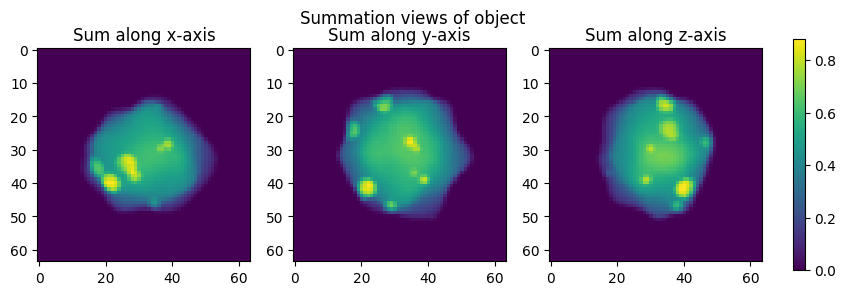

In [ ]:
tomodpdt.plotting.plot_sum_object(volume)

## 2. Load and Visualize the Experimental Background

In [ ]:
fields = np.load('../test_data/glass_coverslip.npy')

The data is stored in a compressed fft-format, and has to be loaded...

In [ ]:
fields = tomodpdt.ft_loader.vec_to_field_multi(fields, pupil_radius=300, shape=(1200, 1200))

In [ ]:
def correctfield(field, n_iter=5):
    """
    Correct field by removing global phase offset using median phase estimation.
    """
    if field.dtype == torch.float32:
        field = field.to(torch.complex64)

    f_new = field.clone()
    f_new = f_new / torch.mean(torch.abs(f_new))  # normalize amplitude

    for _ in range(n_iter):
        f_new = f_new * torch.exp(-1j * torch.median(torch.angle(f_new)))

    return f_new


def add_random_background_crops(
    projections,
    fields,
    correctfield_fn=correctfield,
    device="cpu",
    n_iter_field=3,
    field_scale=0.25,
    threshold=None,
    seed=None,
    return_backgrounds=False,
):
    """
    Add random background crops from experimental fields onto projection frames.

    Parameters
    ----------
    projections : torch.Tensor
        Complex or two-channel tensor of shape (N, 2, H, W), representing simulated projections.
    fields : torch.Tensor
        Tensor of shape (M, Hf, Wf) containing background field images.
    correctfield_fn : callable
        Function to correct field distortions (default = `correctfield`).
    device : str, optional
        Device for computation ('cpu' or 'cuda').
    n_iter_field : int, optional
        Number of correction iterations for field correction.
    field_scale : float, optional
        Scaling factor applied to the added background intensity.
    threshold : float, optional
        If provided, sets all field values below this threshold to zero.
    seed : int, optional
        Random seed for reproducibility.
    return_backgrounds : bool, optional
        If True, also return the cropped/processed background patches used.

    Returns
    -------
    torch.Tensor
        Modified projections with background overlays.
    (optional) torch.Tensor
        The cropped background fields applied to each projection.
    """

    if seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)

    projections = projections.clone().to(device)
    bg_used = []  # store background crops if requested

    for i in range(projections.shape[0]):
        rand_idx = random.randint(0, fields.shape[0] - 1)
        field_bg = fields[rand_idx]

        # Random crop from background field
        x_start = random.randint(0, field_bg.shape[0] - projections.shape[2])
        y_start = random.randint(0, field_bg.shape[1] - projections.shape[3])
        field_crop = field_bg[
            x_start : x_start + projections.shape[2],
            y_start : y_start + projections.shape[3],
        ].to(torch.float32)

        # Optional threshold
        if threshold is not None:
            field_crop[field_crop < threshold] = 0.0

        # Convert to complex and correct
        field_crop = torch.complex(field_crop, torch.zeros_like(field_crop)).to(device)
        field_crop = correctfield_fn(field_crop, n_iter=n_iter_field) * field_scale

        # Correct projection field
        proj_field = torch.complex(projections[i, 0], projections[i, 1]).to(device)
        proj_field = correctfield_fn(proj_field, n_iter=n_iter_field)

        # Add background
        projections[i, 0] = proj_field.real + field_crop.real
        projections[i, 1] = proj_field.imag + field_crop.imag

        if return_backgrounds:
            bg_used.append(field_crop.detach().cpu())

    if return_backgrounds:
        return projections, torch.stack(bg_used)

    return projections

### 2.1 Visualize some of the experimental backgrounds.

In [ ]:
import matplotlib.pyplot as plt

### 2.1 Visualize some of the experimental backgrounds.
n_visualize = 3
fig, axs = plt.subplots(1, n_visualize, figsize=(15, 5))
for i in range(n_visualize):
    rand_idx = random.randint(0, fields.shape[0] - 1)
    axs[i].imshow(np.imag(fields[rand_idx]), cmap='gray')
    axs[i].set_title(f'Field index: {rand_idx}')
    axs[i].axis('off')

## 2. Set Up Brightfield Imaging Model

In [ ]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# --- Setup the optical system ---
optics_settings = setup_optics(
    shape=volume.shape,       # Shape of the 3D volume
    padding_xy=volume.shape[0]//2,  # Padding in the lateral directions (avoids wrap-around effects)
    microscopy_regime='Brightfield', # Choose microscopy type: 'Brightfield', 'Fluorescence', etc.
    NA=1.1,                      # Numerical Aperture of the objective
    wavelength=520e-9,           # Illumination wavelength in meters
    resolution=200e-9,           # Effective pixel resolution in meters
    magnification=1,             # System magnification
    return_field=True            # Return the complex optical field instead of intensity only
)

# --- Build the imaging model ---
brightfield_model = imaging_model(optics_setup=optics_settings)


## 3. Generate Projections

In [ ]:
test_object, q_gt, projections, imaging_model = tomodpdt.simulate.create_data(
    volume=volume, # The volume we want to reconstruct
    image_modality=brightfield_model, # We use the sum model
    rotation_case='random_sinusoidal', # We rotate the object around 1 main axis, but the other 2 axes are also non-zero an
    samples=250, # Number of projections
    duration=2 # Duration is the number of full revolutions
    )

Simulating... 40.0%


Simulating... 80.0%


### 3.2 Visualizing the Training Data

In this section, we explore the generated training data through the forward images and the corresponding rotation parameters.

#### Vizualising the forward projections

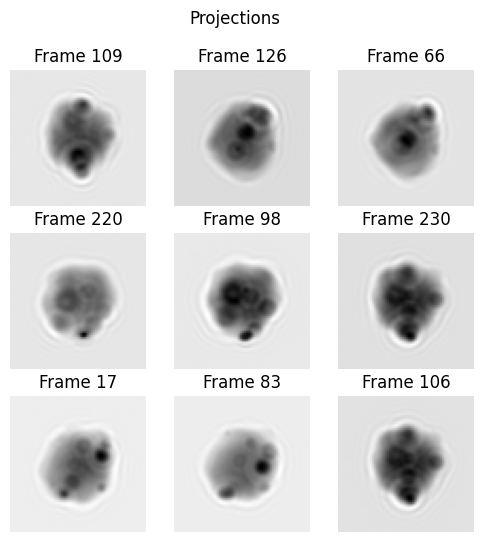

In [ ]:
tomodpdt.plotting.plot_grid33_frames(projections, title="Projections", randomize=True)

#### Visualizing the Quaternion Trajectory

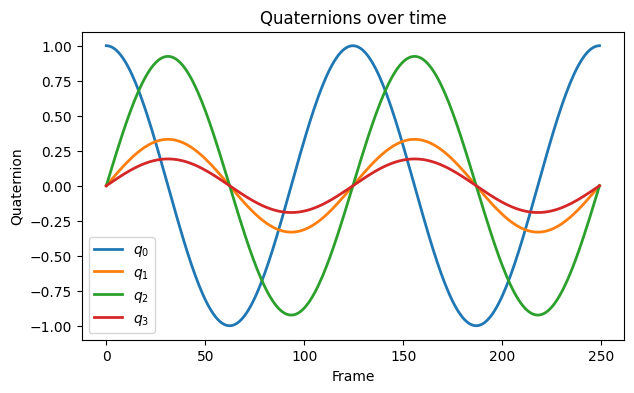

In [ ]:
tomodpdt.plotting.plot_quaternions(q_gt)

## 4. Reconstruct the 3D Volume

In this section, we focus on **tomographic reconstruction**, that is, the process of recovering a 3D volume from a set of 2D projection images acquired under different viewing angles.

#### Create the tomographic model

In [ ]:
tomographic_model = tomodpdt.Tomography(
    volume_size=volume.shape, # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='basis', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model
    )

#### Initialize the parameters

In [ ]:
tomographic_model.initialize_parameters(projections, normalize=False, max_epochs=200)

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name                | Type                 | Params | Mode 
---------------------------------------------------------------------
0 | encoder             | Sequential           | 79.8 K | train
1 | fc_mu               | MultiLayerPerceptron | 32.8 K

c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.



Training: |                                                                                                                                                                                                                              | 0/? [00:00<?, ?it/s]


Training:   0%|                                                                                                                                                                                                                          | 0/8 [00:00<?, ?it/s]


Epoch 0:   0%|                                                                                                                                                                                                                           | 0/8 [00:00<?, ?it/s]

...


Epoch 199:  88%|████████████████████████████████▍    | 7/8 [00:00<00:00, 87.95it/s, v_num=1590, train_rec_loss_step=0.0361, train_KL_step=139.0, train_total_loss_step=0.0374, train_rec_loss_epoch=0.037, train_KL_epoch=144.0, train_total_loss_epoch=0.0384]


Epoch 199: 100%|█████████████████████████████████████| 8/8 [00:00<00:00, 89.40it/s, v_num=1590, train_rec_loss_step=0.0361, train_KL_step=139.0, train_total_loss_step=0.0374, train_rec_loss_epoch=0.037, train_KL_epoch=144.0, train_total_loss_epoch=0.0384]


Epoch 199: 100%|█████████████████████████████████████| 8/8 [00:00<00:00, 89.40it/s, v_num=1590, train_rec_loss_step=0.0361, train_KL_step=121.0, train_total_loss_step=0.0373, train_rec_loss_epoch=0.037, train_KL_epoch=144.0, train_total_loss_epoch=0.0384]


Epoch 199: 100%|████████████████████████████████████| 8/8 [00:00<00:00, 89.40it/s, v_num=1590, train_rec_loss_step=0.0361, train_KL_step=121.0, train_total_loss_step=0.0373, train_rec_loss_epoch=0.0364, train_KL_epoch=135.0, train_total_loss_epoch=0.0377]


Epoch 199: 100%|████████████████████████████████████| 8/8 [00:00<00:00, 71.85it/s, v_num=1590, train_rec_loss_step=0.0361, train_KL_step=121.0, train_total_loss_step=0.0373, train_rec_loss_epoch=0.0364, train_KL_epoch=135.0, train_total_loss_epoch=0.0377]

For vizualisation we initialize a `TomoPlotter` class for easier plotting.

In [ ]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

#### Visualizing the Latent Space Trajectory, Peaks and the Initial Guess


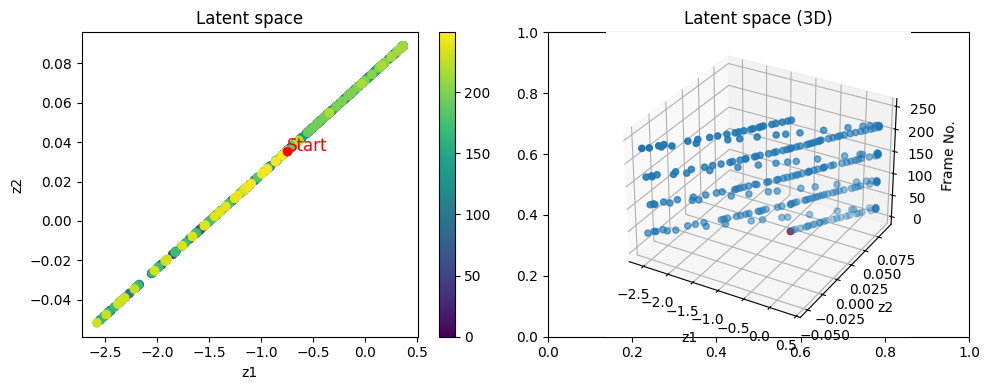

In [ ]:
plotter.plot_latent_space()

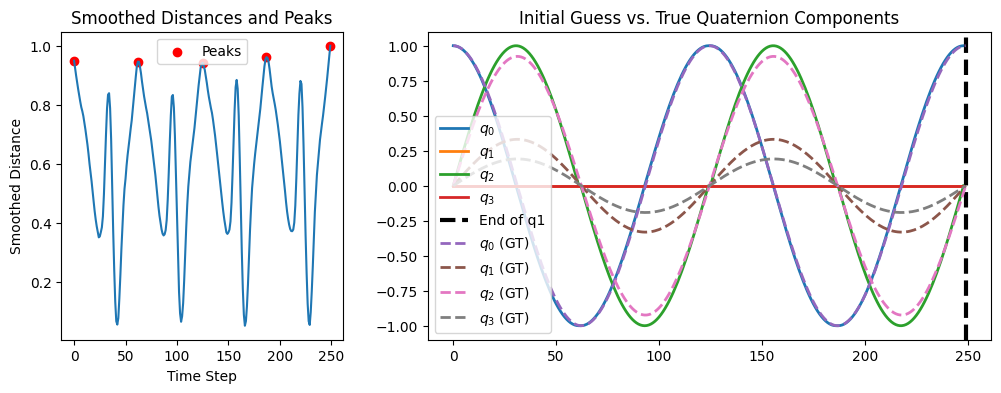

In [ ]:
plotter.plot_smooth_dist_intial_guess(q_gt=q_gt)

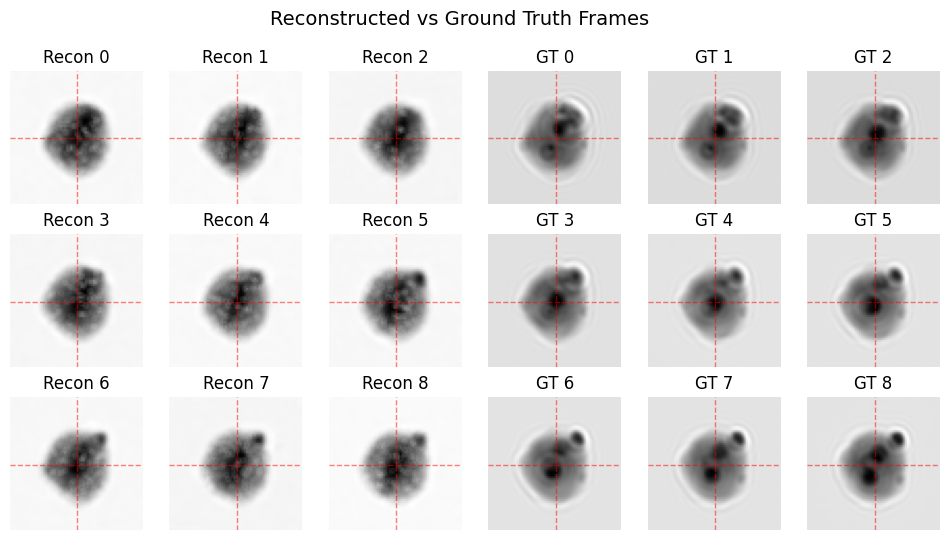

In [ ]:
plotter.plot_reconstructed_vs_gt()


### 4.1 Start the 3D Reconstruction Optimization


In [ ]:
N1 = len(tomographic_model.frames) # Number of frames
idx = torch.arange(N1) # List of indexes
epochs_object_only = 50 # Number of epochs for the object only optimization
batch_size_object_only = 32 # Batch size for the object only optimization

In [ ]:
# Toggle the gradients of the quaternion parameters to False
tomographic_model.toggle_gradients_quaternion(False)

# Toggle the gradients of the translation parameters to False
tomographic_model.toggle_gradients_translation(False)

# Move the model to device and all parameters
tomographic_model.move_all_to_device(DEV)


  | Name          | Type                   | Params | Mode 
-----------------------------------------------------------------
0 | vae_model     | VariationalAutoEncoder | 258 K  | train
1 | encoder       | Sequential             | 79.8 K | train
2 | fc_mu         | MultiLayerPerceptron   | 32.8 K | train
3 | imaging_model | imaging_model          | 0      | train
4 | train_metrics | MetricCollection       | 0      | train
5 | val_metrics   | MetricCollection       | 0      | train
6 | test_metrics  | MetricCollection       | 0      | train
7 | optimizer     | Adam                   | 0      | train
  | other params  | n/a                    | 150 K  | n/a  
-----------------------------------------------------------------
262 K     Trainable params
258 K     Non-trainable params
520 K     Total params
2.084     Total estimated model params size (MB)
83        Modules in train mode
0         Modules in eval mode


c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.



Training: |                                                                                                                                                                                                                              | 0/? [00:00<?, ?it/s]


Training:   0%|                                                                                                                                                                                                                          | 0/8 [00:00<?, ?it/s]


Epoch 0:   0%|                                                                                                                                                                                                                           | 0/8 [00:00<?, ?it/s]

...


Epoch 49: 100%|█| 8/8 [00:01<00:00,  4.03it/s, v_num=1591, train_total_loss_step=0.0477, train_proj_loss_step=0.0314, train_latent_loss_step=0.0121, train_rtv_loss_step=0.00382, train_so_loss_step=0.000408, train_total_loss_epoch=0.0562, train_proj_loss_e


Epoch 49: 100%|█| 8/8 [00:02<00:00,  3.90it/s, v_num=1591, train_total_loss_step=0.0582, train_proj_loss_step=0.0319, train_latent_loss_step=0.022, train_rtv_loss_step=0.00382, train_so_loss_step=0.000429, train_total_loss_epoch=0.0562, train_proj_loss_ep


Epoch 49: 100%|█| 8/8 [00:02<00:00,  3.90it/s, v_num=1591, train_total_loss_step=0.0582, train_proj_loss_step=0.0319, train_latent_loss_step=0.022, train_rtv_loss_step=0.00382, train_so_loss_step=0.000429, train_total_loss_epoch=0.056, train_proj_loss_epo


Epoch 49: 100%|█| 8/8 [00:02<00:00,  3.86it/s, v_num=1591, train_total_loss_step=0.0582, train_proj_loss_step=0.0319, train_latent_loss_step=0.022, train_rtv_loss_step=0.00382, train_so_loss_step=0.000429, train_total_loss_epoch=0.056, train_proj_loss_epo


Training time:  1.7387178222338358  minutes


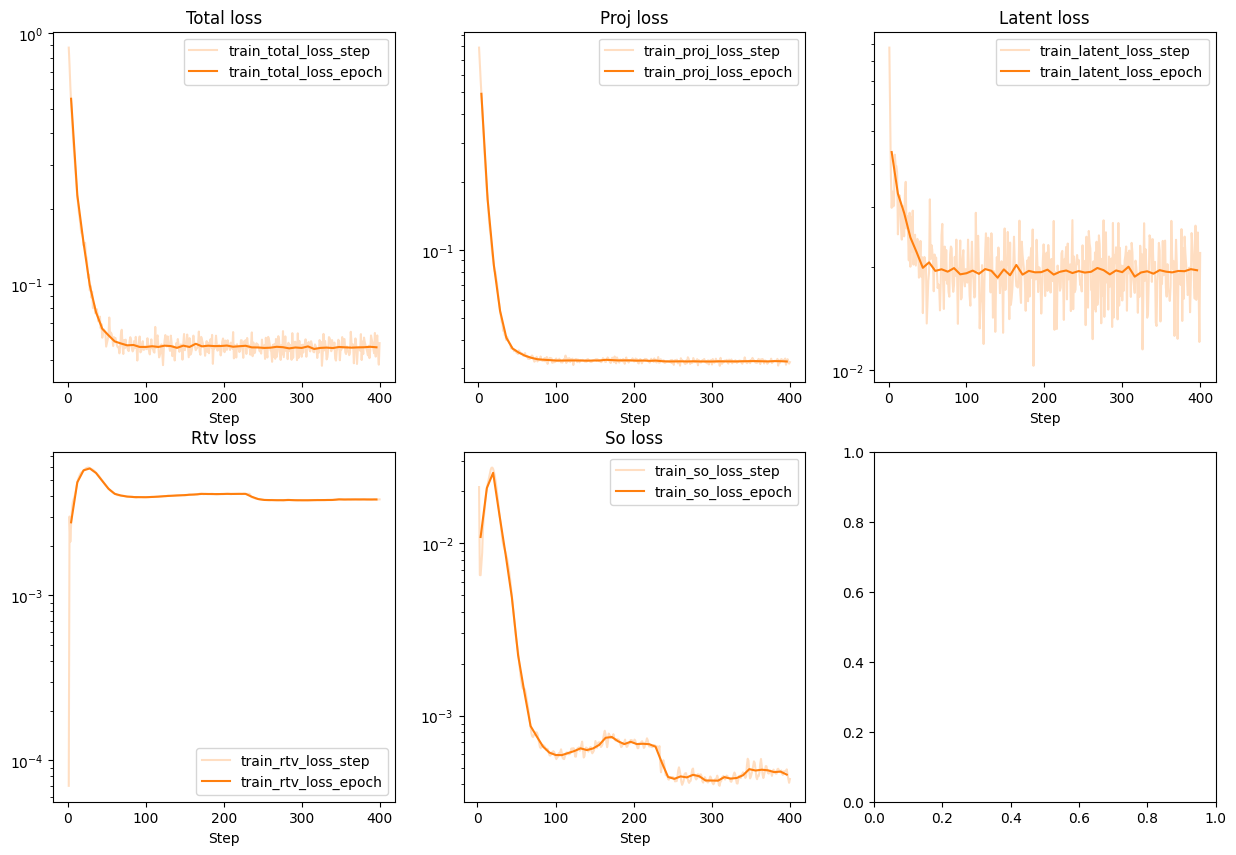

In [ ]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_only, accelerator="auto", log_every_n_steps=10)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

### 4.2 Optimize the 3D volume and the rotation parameters

In [ ]:
epochs_object_rot = 500 # Number of epochs for the object and rotation optimization
batch_size_object_rot = 32 # Batch size for the object and rotation optimization

In [ ]:
# Toggle the gradients of the quaternion parameters
tomographic_model.toggle_gradients_quaternion(True)

# The gradients of the translation parameters are already False and remain so since we do not want to optimize them now
# tomographic_model.toggle_gradients_translation(False)

# Move the model to device
tomographic_model.move_all_to_device(DEV)

and train the model for `epochs_object_rot` epochs...


  | Name          | Type                   | Params | Mode 
-----------------------------------------------------------------
0 | vae_model     | VariationalAutoEncoder | 258 K  | train
1 | encoder       | Sequential             | 79.8 K | train
2 | fc_mu         | MultiLayerPerceptron   | 32.8 K | train
3 | imaging_model | imaging_model          | 0      | train
4 | train_metrics | MetricCollection       | 0      | train
5 | val_metrics   | MetricCollection       | 0      | train
6 | test_metrics  | MetricCollection       | 0      | train
7 | optimizer     | Adam                   | 0      | train
  | other params  | n/a                    | 150 K  | n/a  
-----------------------------------------------------------------
262 K     Trainable params
258 K     Non-trainable params
520 K     Total params
2.084     Total estimated model params size (MB)
83        Modules in train mode
0         Modules in eval mode



Training: |                                                                                                                                                                                                                              | 0/? [00:00<?, ?it/s]


Training:   0%|                                                                                                                                                                                                                          | 0/8 [00:00<?, ?it/s]


Epoch 0:   0%|                                                                                                                                                                                                                           | 0/8 [00:00<?, ?it/s]


Epoch 0:  12%|██████████████████████████▍                                                                                                                                                                                        | 1/8 [00:00<00:01,  4.00it/s]

...


Epoch 499: 100%|█| 8/8 [00:02<00:00,  3.18it/s, v_num=1592, train_total_loss_step=0.00297, train_proj_loss_step=0.000157, train_latent_loss_step=5.62e-5, train_rtv_loss_step=0.00276, train_so_loss_step=2.07e-9, train_total_loss_epoch=0.00299, train_proj_l


Epoch 499: 100%|█| 8/8 [00:02<00:00,  3.18it/s, v_num=1592, train_total_loss_step=0.00313, train_proj_loss_step=0.000256, train_latent_loss_step=0.000117, train_rtv_loss_step=0.00276, train_so_loss_step=2.32e-9, train_total_loss_epoch=0.00299, train_proj_


Epoch 499: 100%|█| 8/8 [00:02<00:00,  3.17it/s, v_num=1592, train_total_loss_step=0.00313, train_proj_loss_step=0.000256, train_latent_loss_step=0.000117, train_rtv_loss_step=0.00276, train_so_loss_step=2.32e-9, train_total_loss_epoch=0.00298, train_proj_


Epoch 499: 100%|█| 8/8 [00:02<00:00,  3.15it/s, v_num=1592, train_total_loss_step=0.00313, train_proj_loss_step=0.000256, train_latent_loss_step=0.000117, train_rtv_loss_step=0.00276, train_so_loss_step=2.32e-9, train_total_loss_epoch=0.00298, train_proj_


Training time:  21.111131417751313  minutes


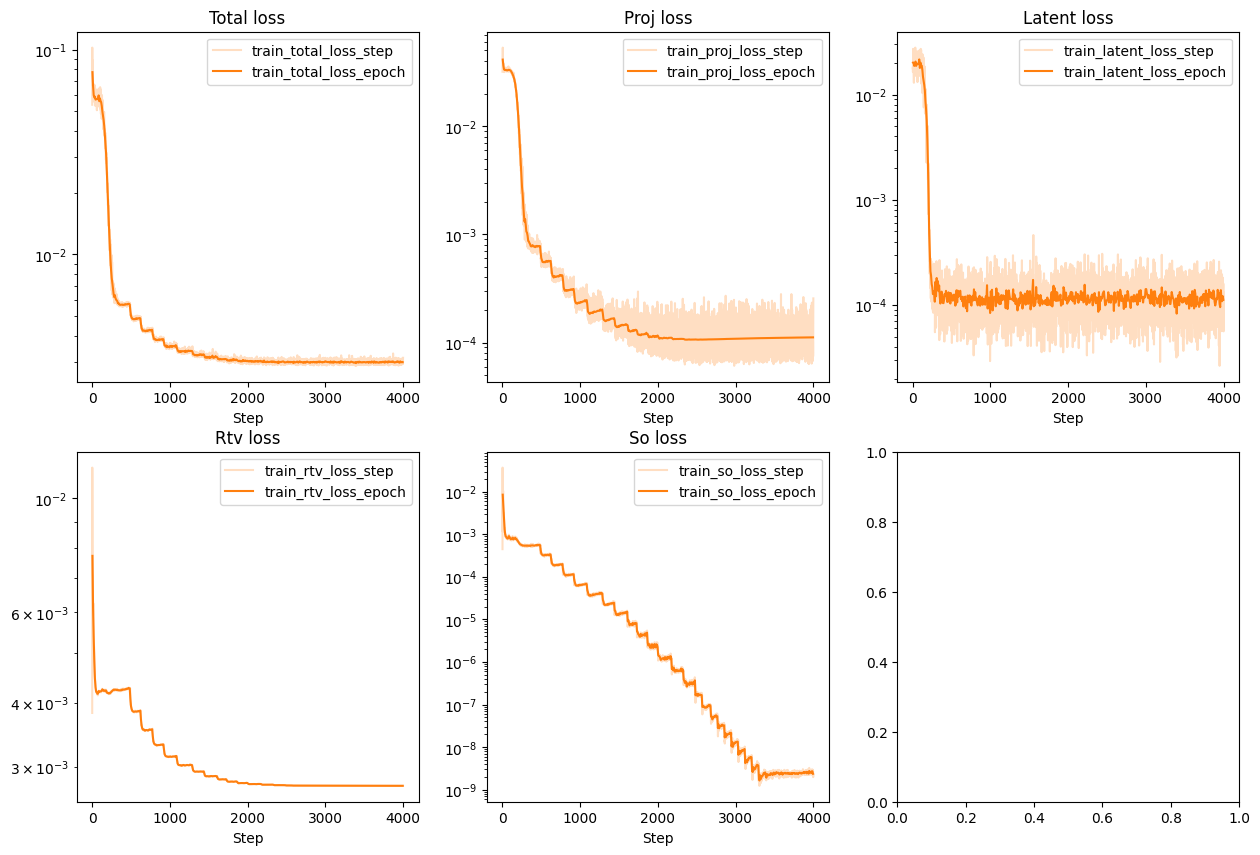

In [ ]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_rot, accelerator="auto", log_every_n_steps=None)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_rot , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

## 5.  Evaluate & Visualize

In [ ]:
# Move it to the GPU if possible for faster plotting
tomographic_model.move_all_to_device(DEV)

# Visualize the final volume and rotations.
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

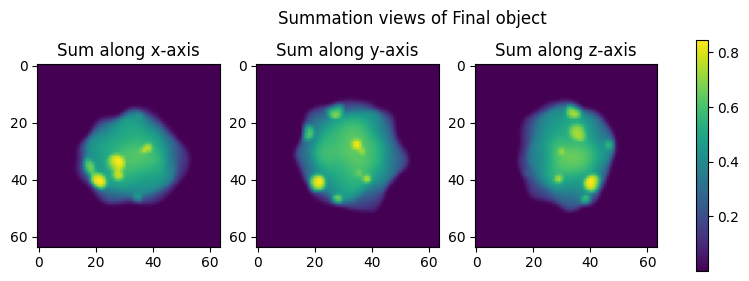

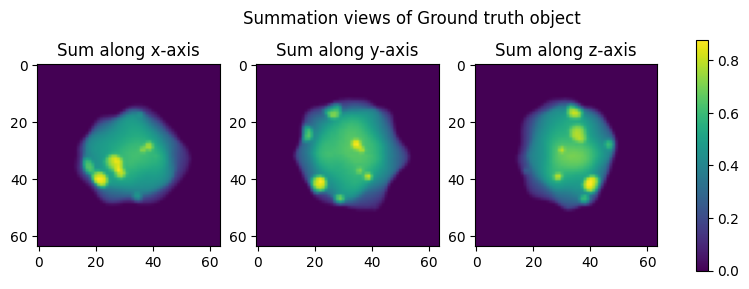

In [ ]:
plotter.plot_sum_object(save_name="Final object")
plotter.plot_sum_object(obj=test_object.cpu(), save_name="Ground truth object")

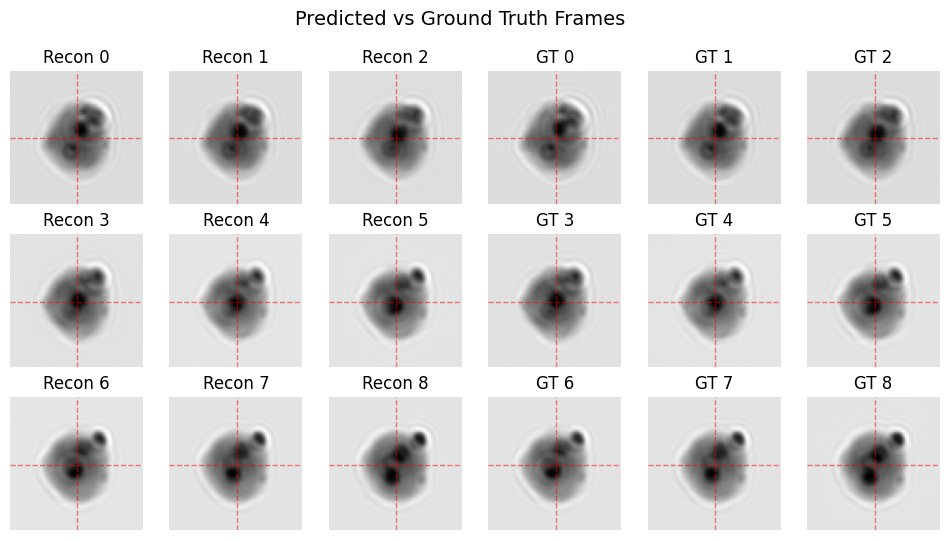

In [ ]:
plotter.plot_reconstructed_vs_gt(column_headers=["Predicted", "Ground Truth"], forward=True, save_name="Reconstructed vs GT")

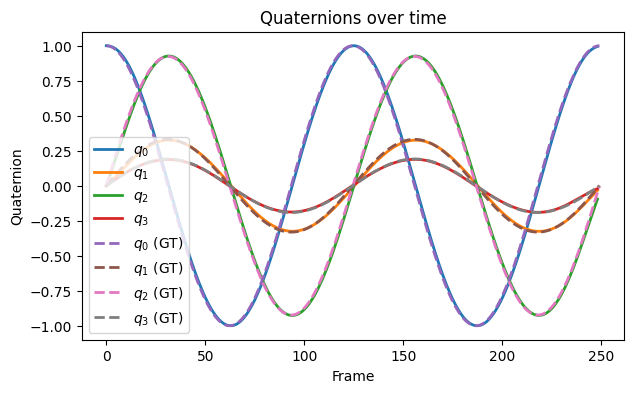

In [ ]:
plotter.plot_quaternions(q_gt=q_gt)

The most effective way to visualize and compare the reconstructed volume to the ground truth is through interactive 3D plots using `plotly`.

In [ ]:
# Uncomment belowto visualize the 3D volume
# tomodpdt.plotting.visualize_3d_volume(tomographic_model.volume.detach().cpu(), save_name="Final object 3D")
# tomodpdt.plotting.visualize_3d_volume(test_object.cpu(), save_name="Ground truth object 3D")

## 6. Save Result

Once the process is complete, we can save the reconstructed volume and the quaternion parameters to `numpy` arrays.

In [ ]:
# Define where to save the reconstruction results
# save_folder = "path/to/save/folder"

# --- Save the reconstructed 3D volume ---
# Extract the optimized volume from the model and save as a NumPy array
# volume = tomographic_model.get_volume().detach().cpu().numpy()
# np.save(f"{save_folder}/volume.npy", volume)

# --- Save the optimized quaternions ---
# Extract the final quaternion parameters and save them as a NumPy array
# quaternions_pred = tomographic_model.get_quaternions_final().detach().cpu().numpy()
# np.save(f"{save_folder}/quaternions.npy", quaternions_pred)

